In [4]:
import pandas as pd

df_review_order = pd.read_csv(
    "../data/analysis/review_order_summary.csv"
)

df_delivery = pd.read_csv(
    "../data/analysis/delivery_delay_review_summary.csv"
)

df_merge = pd.merge(
    df_review_order,
    df_delivery[["order_id", "delivery_delay_days"]],
    on="order_id",
    how="inner"
)

print(df_merge.shape)
print(df_merge.head())
print(df_merge.isna().sum())

(95830, 5)
                           order_id  review_score  total_price  total_freight  \
0  0005a1a1728c9d785b8e2b08b904576c           1.0       145.95          11.65   
1  000aed2e25dbad2f9ddb70584c5a2ded           1.0       144.00           8.77   
2  00169e31ef4b29deaae414f9a5e95929           1.0        39.00          16.11   
3  0017afd5076e074a48f1f1a4c7bac9c5           1.0       809.10          44.29   
4  001d8f0e34a38c37f7dba2a37d4eba8b           1.0        37.98          15.56   

   delivery_delay_days  
0                    0  
1                   -4  
2                  -15  
3                    4  
4                    2  
order_id               0
review_score           0
total_price            0
total_freight          0
delivery_delay_days    0
dtype: int64


In [ ]:
# 低評価の定義

df_merge["low_review"] = (
    df_merge["review_score"] <= 2
).astype(int)

In [6]:
print(
    df_merge["low_review"]
    .value_counts()
    .sort_index()
)

print(
    df_merge["low_review"]
    .value_counts(normalize=True)
    .sort_index()
)

low_review
0    83590
1    12240
Name: count, dtype: int64
low_review
0    0.872274
1    0.127726
Name: proportion, dtype: float64


In [7]:
features = [
    "total_price",
    "total_freight",
    "delivery_delay_days"
]

print(df_merge[features].describe())

        total_price  total_freight  delivery_delay_days
count  95830.000000   95830.000000         95830.000000
mean     136.798400      22.762521           -11.914067
std      207.782774      21.522100            10.113511
min        0.850000       0.000000          -147.000000
25%       45.900000      13.840000           -17.000000
50%       86.250000      17.160000           -12.000000
75%      149.900000      23.990000            -7.000000
max    13440.000000    1794.960000           188.000000


In [ ]:
from sklearn.model_selection import train_test_split

features = [
    "total_price",
    "total_freight",
    "delivery_delay_days"
]

# Xが特徴量、yが目的変数
X = df_merge[features]
y = df_merge["low_review"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2, # データの20%をテストデータに
    random_state=42, # 再現性の確保
    stratify=y # y(低評価率)を維持して分割
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:")
print(y_train.value_counts(normalize=True))
print("y_test:")
print(y_test.value_counts(normalize=True))

X_train: (76664, 3)
X_test : (19166, 3)
y_train:
low_review
0    0.872274
1    0.127726
Name: proportion, dtype: float64
y_test:
low_review
0    0.872274
1    0.127726
Name: proportion, dtype: float64


In [10]:
# 変数スケールがかなり違うので標準化

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [12]:
from sklearn.linear_model import LogisticRegression

model_LogisticRegression = LogisticRegression(
    random_state=42,
    max_iter=1000
)

model_LogisticRegression.fit(X_train_scaled, y_train)

print(model_LogisticRegression)
print("classed:", model_LogisticRegression.classes_)
print("coefficients:", model_LogisticRegression.coef_)
print("intercept:", model_LogisticRegression.intercept_)

LogisticRegression(max_iter=1000, random_state=42)
classed: [0 1]
coefficients: [[0.00839762 0.23740086 0.77466229]]
intercept: [-2.10634883]


In [14]:
import numpy as np

odds_ratios = np.exp(
    model_LogisticRegression.coef_[0]
)

coef_summary = pd.DataFrame({
    "feature": features,
    "coefficient": model_LogisticRegression.coef_[0],
    "odds_ratio": odds_ratios
})

coef_summary

,feature,coefficient,odds_ratio
0,total_price,0.008398,1.008433
1,total_freight,0.237401,1.267949
2,delivery_delay_days,0.774662,2.169859


In [17]:
y_pred = model_LogisticRegression.predict(
    X_test_scaled
)

y_prob = model_LogisticRegression.predict_proba(
    X_test_scaled
)

print("予測結果:")
print(y_pred[:20])

print("\n予測確率:")
print(y_prob[:5])

予測結果:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]

予測確率:
[[0.88718271 0.11281729]
 [0.82783726 0.17216274]
 [0.93009553 0.06990447]
 [0.9625737  0.0374263 ]
 [0.91950657 0.08049343]]


In [21]:
from sklearn.metrics import confusion_matrix

Confusion_matrix = confusion_matrix(
    y_test,
    y_pred
)

print(Confusion_matrix)

[[16625    93]
 [ 2233   215]]


In [22]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

Accuracy : 0.8786
Precision: 0.6981
Recall   : 0.0878
F1-score : 0.1560


In [24]:
y_prob_low = y_prob[:, 1]

print(y_prob_low[:20])

print("最小値:", y_prob_low.min())
print("最大値:", y_prob_low.max())
print("中央値:", y_prob_low.median() if hasattr(y_prob_low, "median") else np.median(y_prob_low))

[0.11281729 0.17216274 0.06990447 0.0374263  0.08049343 0.10766821
 0.05770987 0.07450028 0.36075793 0.06850459 0.03139802 0.09289376
 0.05603154 0.16997559 0.05247176 0.06740618 0.09867107 0.12201212
 0.01976683 0.12143687]
最小値: 6.37577089135474e-06
最大値: 0.9999906163277655
中央値: 0.1035374605237801


In [25]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(
    y_test,
    y_prob_low
)

print(f"ROC-AUC: {roc_auc:.4f}")

ROC-AUC: 0.6744


In [35]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob_low
)

print("FPR:", fpr[:10])
print("TPR:", tpr[:10])
print("Thresholds:", thresholds[:10])



FPR: [0.         0.         0.00011963 0.00011963 0.00023926 0.00023926
 0.00047853 0.00047853 0.00053834 0.00053834]
TPR: [0.         0.0004085  0.0004085  0.00122549 0.00122549 0.00163399
 0.00163399 0.00204248 0.00204248 0.00367647]
Thresholds: [       inf 0.99999062 0.9999817  0.99994415 0.99979328 0.99975751
 0.99778557 0.9962685  0.99364439 0.97011741]


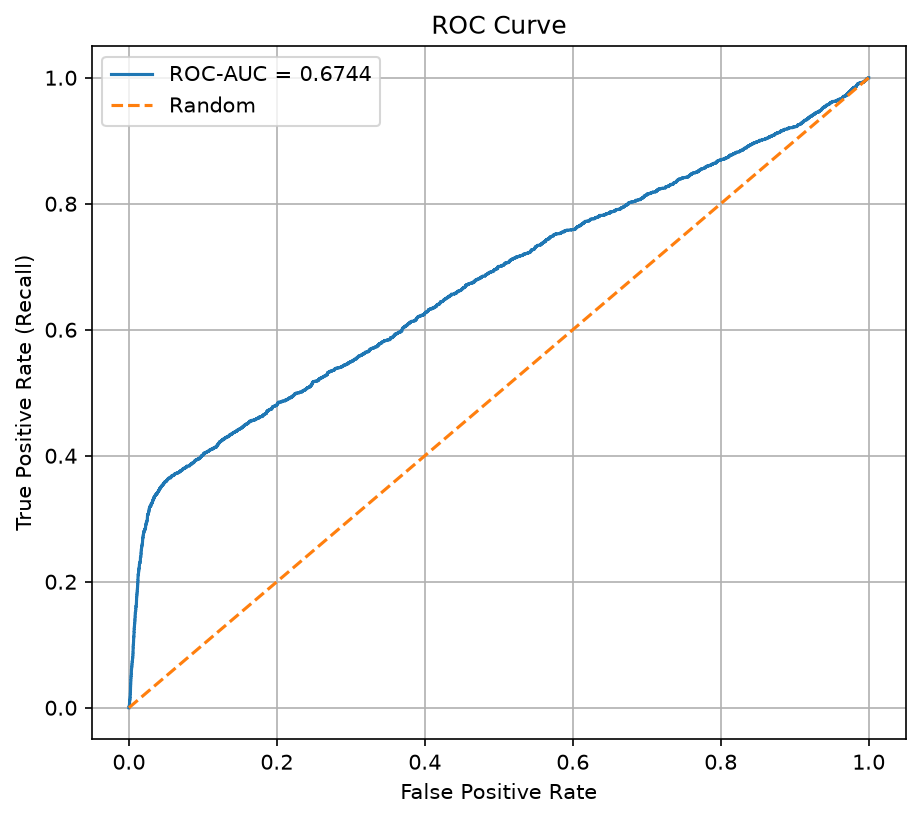

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    label=f"ROC-AUC = {roc_auc:.4f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve")
plt.legend()
plt.grid()
plt.show()

In [38]:
# しきい値を30%へ減少

threshold = 0.30

y_pred_30 = (
    y_prob_low >= threshold
).astype(int)

print(y_pred_30[:20])

accuracy_30 = accuracy_score(y_test, y_pred_30)
precision_30 = precision_score(y_test, y_pred_30)
recall_30 = recall_score(y_test, y_pred_30)
f1_30 = f1_score(y_test, y_pred_30)

print(f"Accuracy : {accuracy_30:.4f}")
print(f"Precision: {precision_30:.4f}")
print(f"Recall   : {recall_30:.4f}")
print(f"F1-score : {f1_30:.4f}")

[0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0]
Accuracy : 0.8901
Precision: 0.6778
Recall   : 0.2663
F1-score : 0.3824


In [39]:
# しきい値を一気に比較

thresholds_to_test = [0.50, 0.40, 0.30, 0.20, 0.10]

results = []

for threshold in thresholds_to_test:

    y_pred_threshold = (
        y_prob_low >= threshold
    ).astype(int)

    results.append({
        "threshold": threshold,
        "accuracy": accuracy_score(y_test, y_pred_threshold),
        "precision": precision_score(y_test, y_pred_threshold),
        "recall": recall_score(y_test, y_pred_threshold),
        "f1": f1_score(y_test, y_pred_threshold)
    })

threshold_results = pd.DataFrame(results)

threshold_results

,threshold,accuracy,precision,recall,f1
0,0.5,0.878639,0.698052,0.087827,0.156023
1,0.4,0.883961,0.710526,0.154412,0.253691
2,0.3,0.890118,0.677755,0.266340,0.382405
3,0.2,0.852969,0.417558,0.382761,0.399403
4,0.1,0.525305,0.170139,0.700572,0.273787


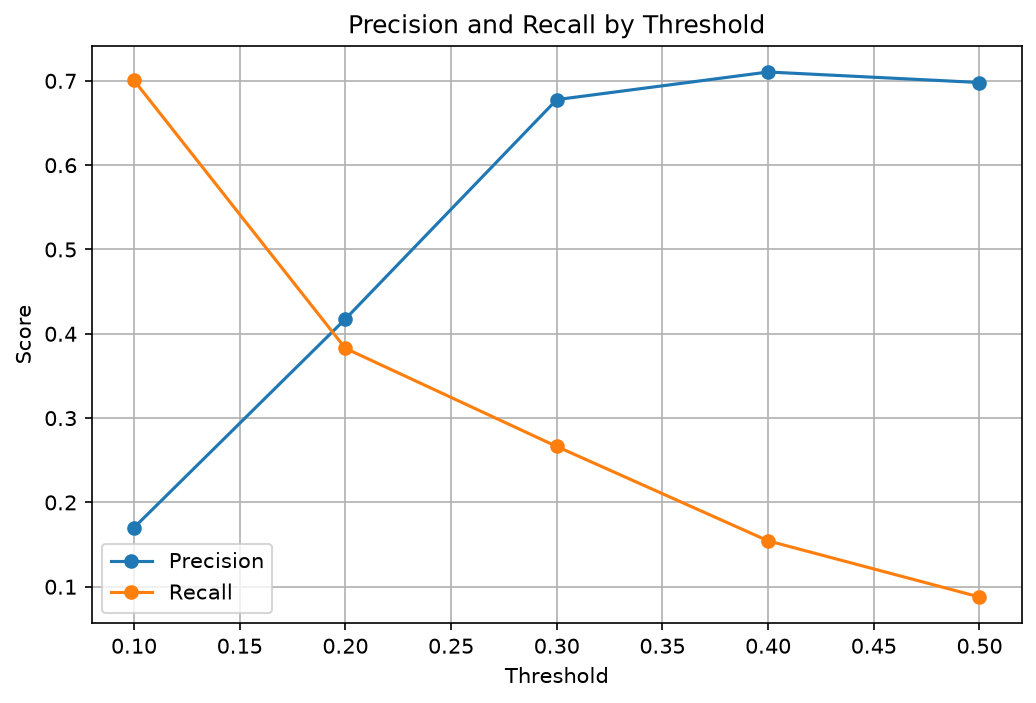

In [40]:
plt.figure(figsize=(8, 5))

plt.plot(
    threshold_results["threshold"],
    threshold_results["precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_results["threshold"],
    threshold_results["recall"],
    marker="o",
    label="Recall"
)

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision and Recall by Threshold")
plt.legend()
plt.grid()
plt.show()

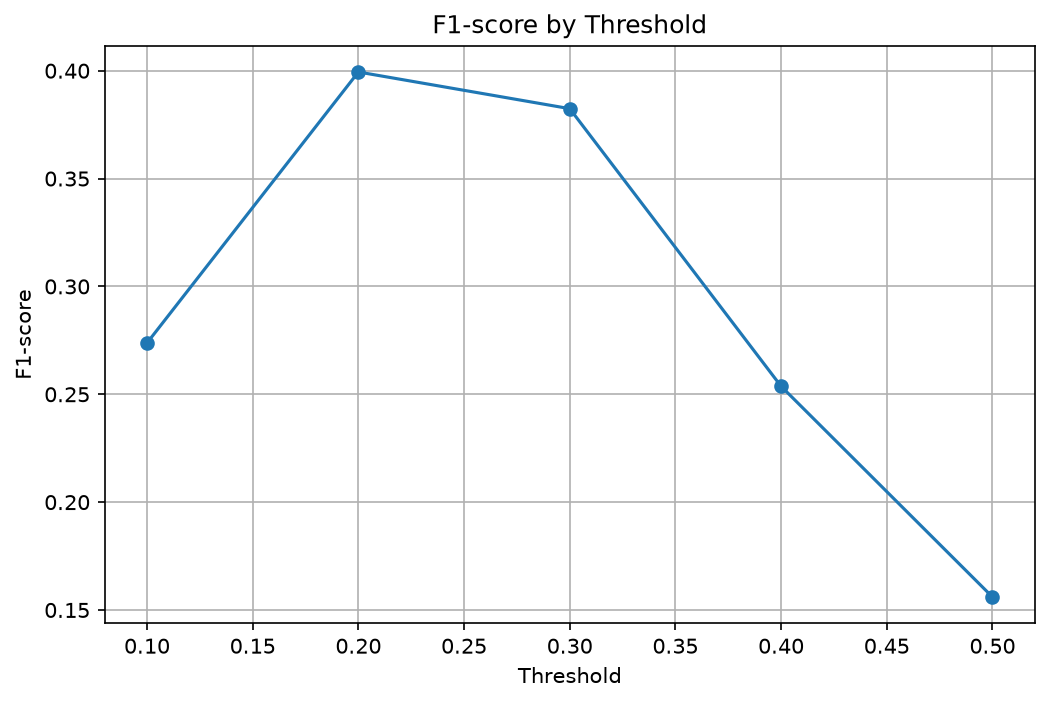

In [41]:
plt.figure(figsize=(8, 5))

plt.plot(
    threshold_results["threshold"],
    threshold_results["f1"],
    marker="o"
)

plt.xlabel("Threshold")
plt.ylabel("F1-score")
plt.title("F1-score by Threshold")
plt.grid()
plt.show()

In [42]:
from sklearn.metrics import precision_recall_curve

precision, recall, pr_thresholds = precision_recall_curve(
    y_test,
    y_prob_low
)

print("Precision:", precision[:10])
print("Recall:", recall[:10])
print("Thresholds:", pr_thresholds[:10])

Precision: [0.12772618 0.12773285 0.12773951 0.12774618 0.12775284 0.12775951
 0.12776618 0.12777285 0.12777952 0.12778619]
Recall: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Thresholds: [6.37577089e-06 8.76731919e-06 5.28287318e-04 7.23266505e-04
 7.49157529e-04 9.14780691e-04 1.24545141e-03 1.24741797e-03
 1.59592867e-03 1.79153583e-03]


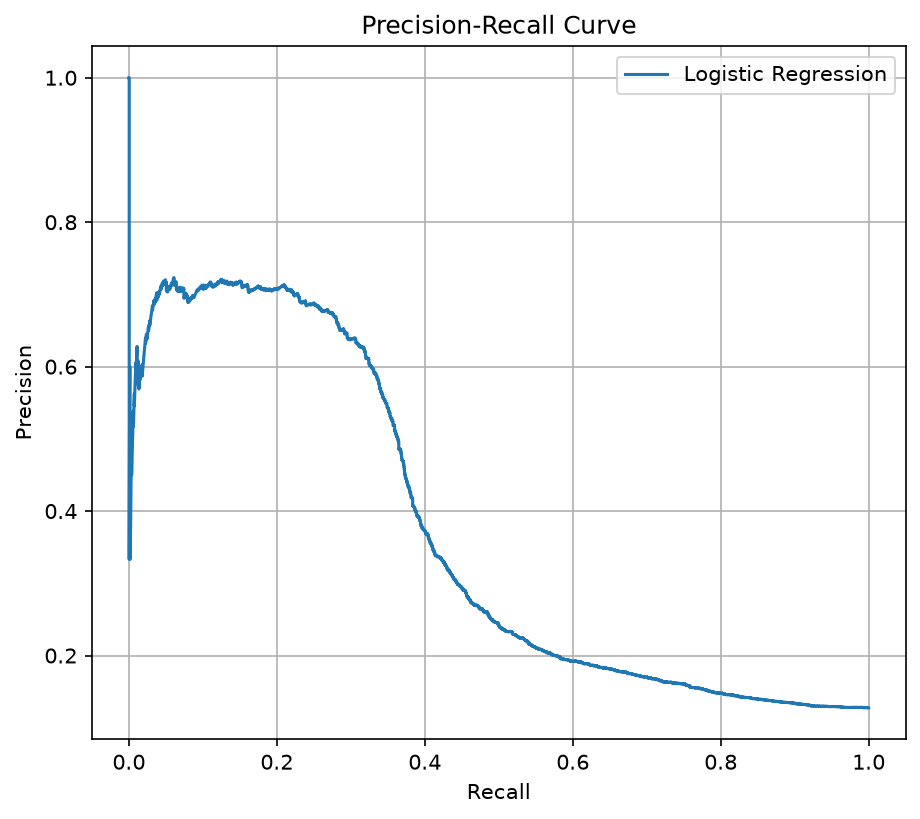

In [43]:
plt.figure(figsize=(7, 6))

plt.plot(
    recall,
    precision,
    label="Logistic Regression"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid()

plt.show()